In [4]:
# Display all column names to verify the correct names
print(train_df.columns)


Index(['category', 'sub_category', 'crimeaditionalinfo'], dtype='object')


In [1]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Load the training dataset
train_df = pd.read_csv('data/train.csv')

# Display basic information and preview
train_df.info()
train_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93686 entries, 0 to 93685
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   category            93686 non-null  object
 1   sub_category        87095 non-null  object
 2   crimeaditionalinfo  93665 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


,category,sub_category,crimeaditionalinfo
0,Online and Social Media Related Crime,Cyber Bullying Stalking Sexting,I had continue received random calls and abusi...
1,Online Financial Fraud,Fraud CallVishing,The above fraudster is continuously messaging ...
2,Online Gambling Betting,Online Gambling Betting,He is acting like a police and demanding for m...
3,Online and Social Media Related Crime,Online Job Fraud,In apna Job I have applied for job interview f...
4,Online Financial Fraud,Fraud CallVishing,I received a call from lady stating that she w...


In [3]:
# Check for missing values in each column
train_df.isnull().sum()


category                 0
sub_category          6591
crimeaditionalinfo      21
dtype: int64

In [6]:
# Display the unique categories and their counts
print("Category distribution:")
print(train_df['category'].value_counts())

# Display the unique subcategories and their counts
print("\nSubcategory distribution:")
print(train_df['sub_category'].value_counts())


Category distribution:
category
Online Financial Fraud                                  57434
Online and Social Media Related Crime                   12140
Any Other Cyber Crime                                   10878
Cyber Attack/ Dependent Crimes                           3608
RapeGang Rape RGRSexually Abusive Content                2822
Sexually Obscene material                                1838
Hacking  Damage to computercomputer system etc           1710
Sexually Explicit Act                                    1552
Cryptocurrency Crime                                      480
Online Gambling  Betting                                  444
Child Pornography CPChild Sexual Abuse Material CSAM      379
Online Cyber Trafficking                                  183
Cyber Terrorism                                           161
Ransomware                                                 56
Report Unlawful Content                                     1
Name: count, dtype: int64

Subcategory

In [7]:
# Check for missing values in each column
missing_values = train_df.isnull().sum()
print("Missing values per column:\n", missing_values)


Missing values per column:
 category                 0
sub_category          6591
crimeaditionalinfo      21
dtype: int64


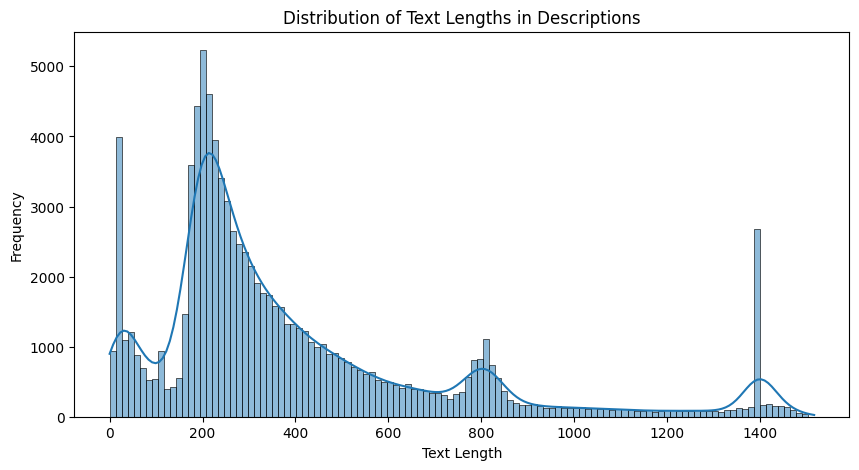

In [11]:
# Fill missing values in 'crimeaditionalinfo' with an empty string
train_df['crimeaditionalinfo'] = train_df['crimeaditionalinfo'].fillna('')

# Calculate and plot the length of text descriptions in characters
train_df['text_length'] = train_df['crimeaditionalinfo'].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(train_df['text_length'], kde=True)
plt.title('Distribution of Text Lengths in Descriptions')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()


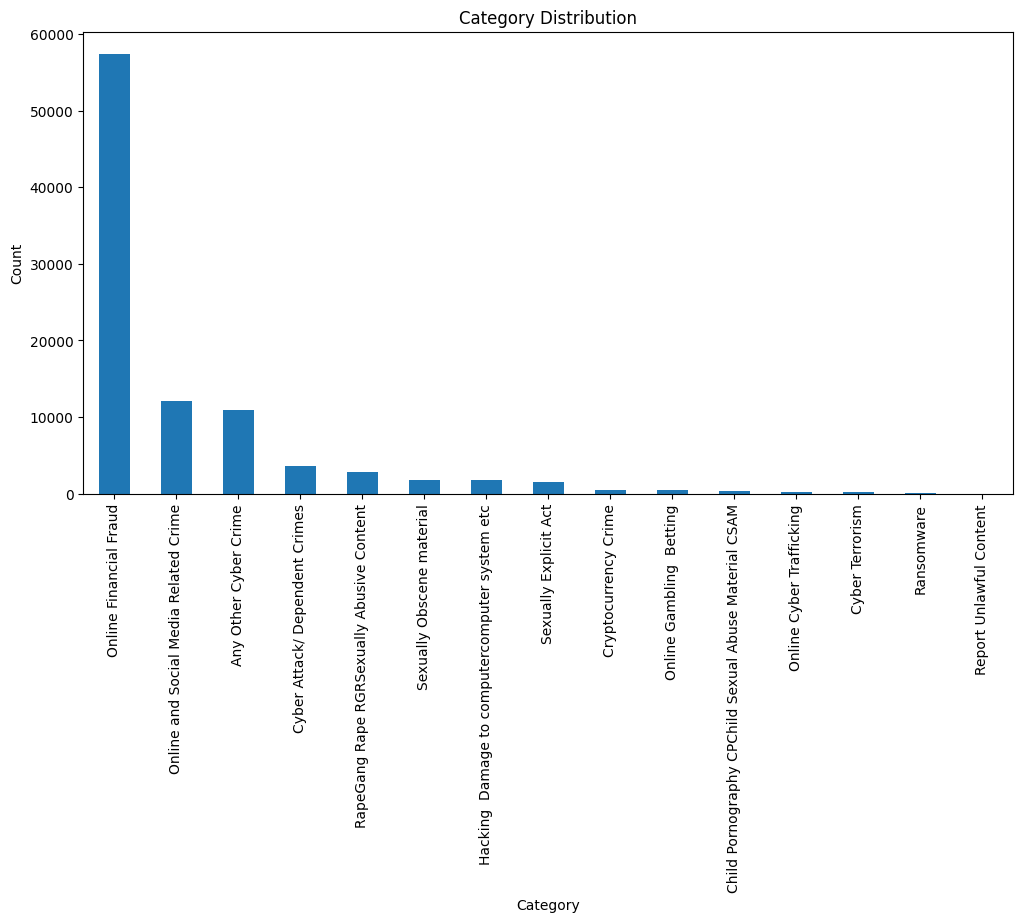

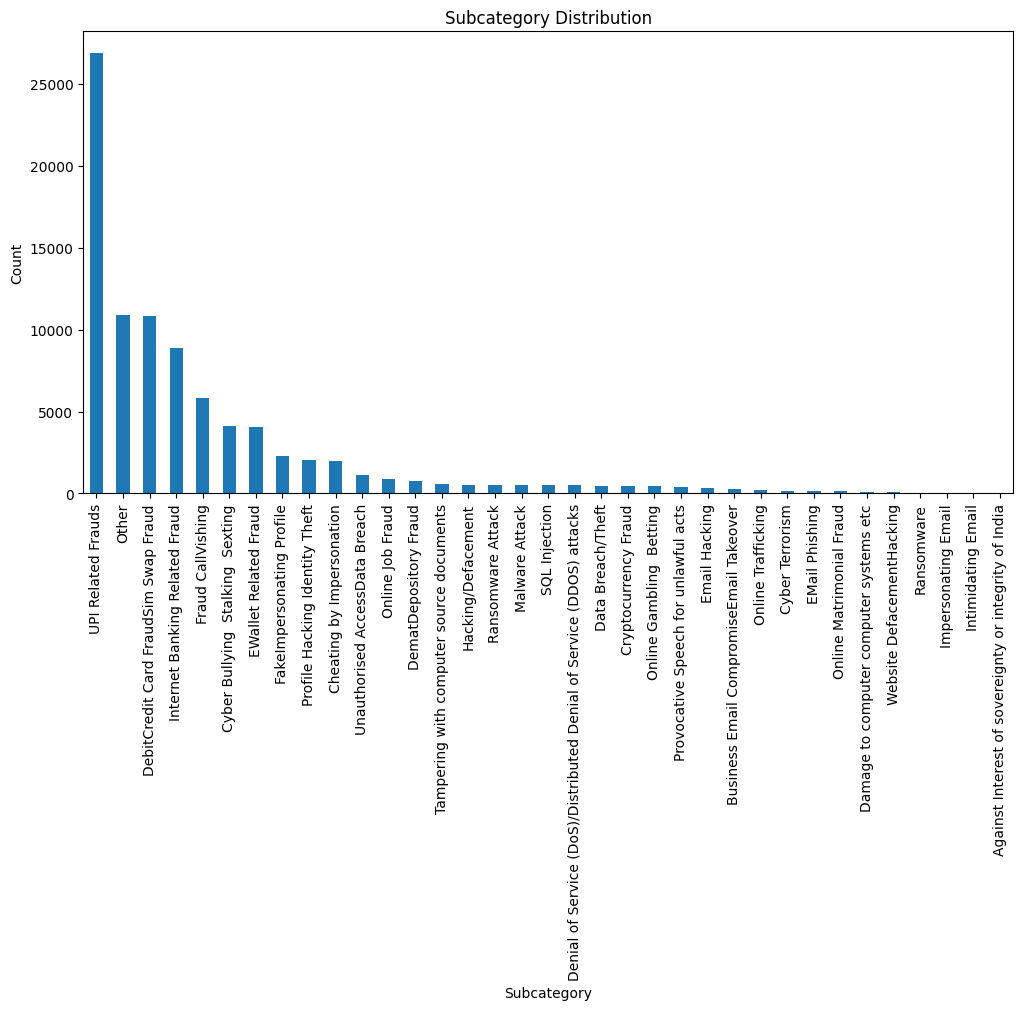

In [12]:
# Plot category distribution
plt.figure(figsize=(12, 6))
train_df['category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Plot subcategory distribution
plt.figure(figsize=(12, 6))
train_df['sub_category'].value_counts().plot(kind='bar')
plt.title("Subcategory Distribution")
plt.xlabel("Subcategory")
plt.ylabel("Count")
plt.show()


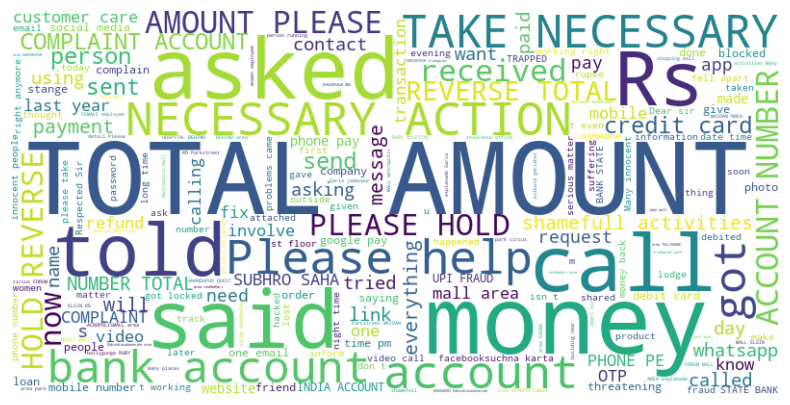

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text descriptions into a single string
all_text = ' '.join(train_df['crimeaditionalinfo'].dropna().astype(str).values)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



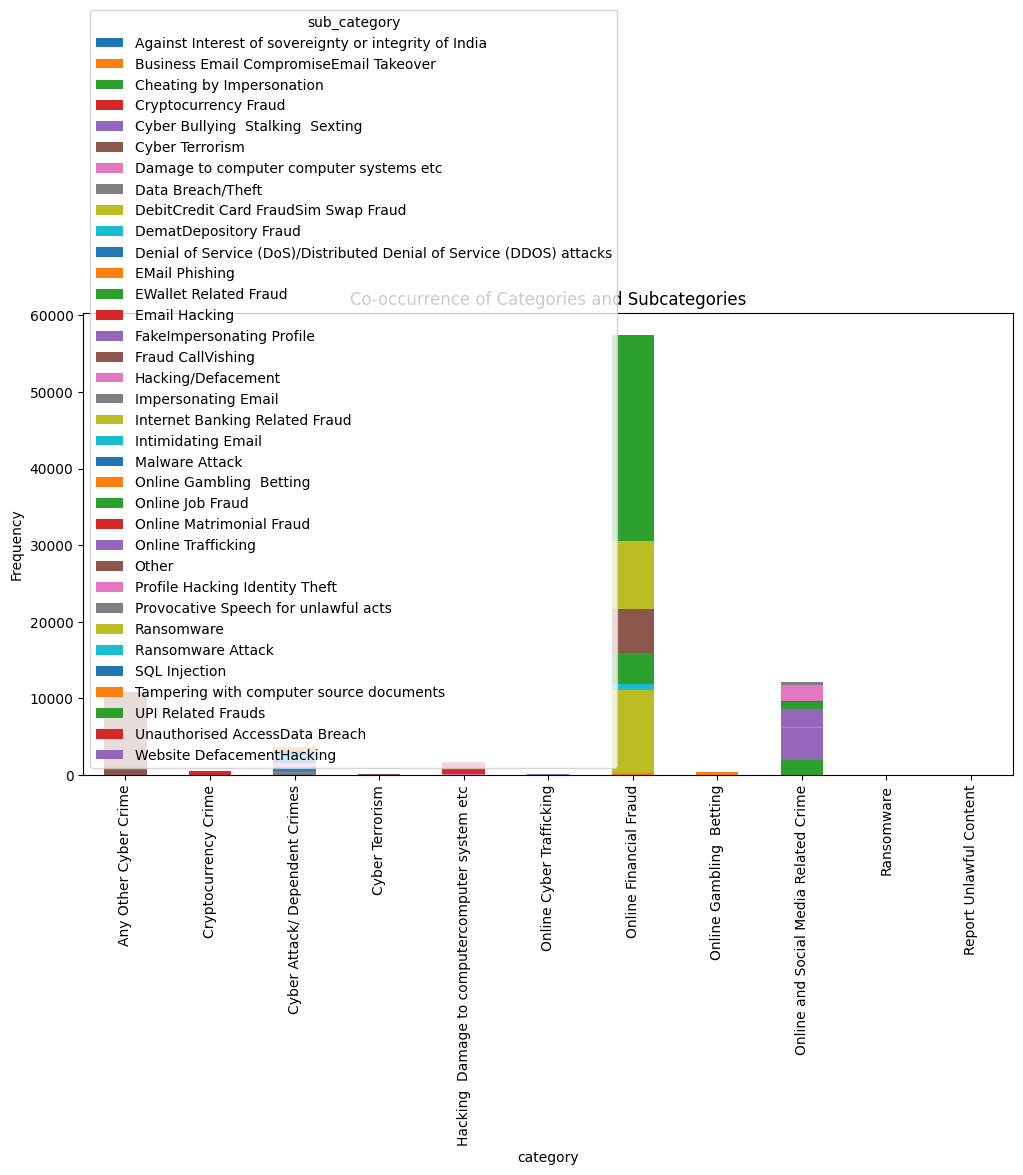

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
train_df = pd.read_csv('data/train.csv')  # Ensure this path points to your actual file location

# Cross-tabulation between category and sub_category
category_subcategory_counts = pd.crosstab(train_df['category'], train_df['sub_category'])
category_subcategory_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Co-occurrence of Categories and Subcategories")
plt.ylabel("Frequency")
plt.show()
